In [1]:
import torch
import numpy as np

# 梯度
1. 梯度测本意是一个向量（矢量），表示某一函数在该点处的方向导数沿着该方向取得最大值，即函数在该点处沿着该方向（此梯度的方向）变化最快，增加幅度最大，换句话说，对于给定函数，该点函数沿梯度方向变化率最大(为该梯度的模)。
## 理解梯度
1. 考虑一座高度在(x,y)点H(x,y)的山。H这一点的梯度是在该点坡度(或者说斜度)最陡峭的方向。梯度大大小告诉我们坡度有多陡，而梯度的方向告诉我们沿着哪个方向下山最快。

## 如何计算梯度
1. 当在离散的位置进行评估与对比分析时，估计下降方向的差异
2. 把这个事情转换成数学公式，就是计算loss对于每个参数的偏微分导数，然后在一个具体点位获得的矢量就是梯度结果

## 梯度下降
1. 导数值的正负来表示方向，如果导数的值是正数，那么就代表x轴的正方向，如果导数的值是负数，那么就代表x轴的负方向，梯度下降法的目标是搜索出来一个能损失函数的值尽可能小的小的位置。
##　反向传播
1. 由于深度学习网络按层深入，层层嵌套的特点，对深度网络目标函数计算梯度的时候，需要用反向传播的方式由深到浅倒着计算以及更新参数。所以反向传播法是梯度下降法在深度网络上的具体实现方式。

## 如何计算梯度
1. 损失函数 L=(t_p-t_c)^2
2. 梯度计算 

In [1]:
%matplotlib inline
import numpy as np
import torch
torch.set_printoptions(edgeitems=2,linewidth=75)

In [2]:
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0] 
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]

In [3]:
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

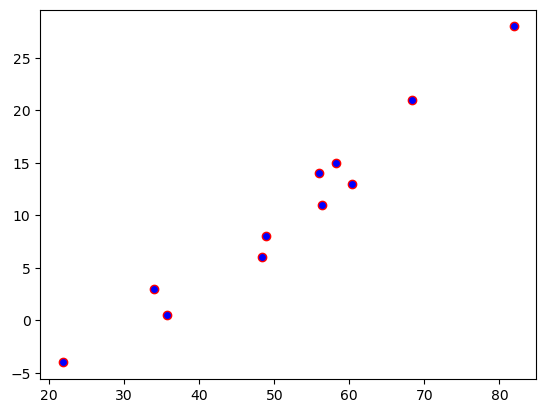

In [4]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.scatter(t_u,t_c,c='b',edgecolor='r')
plt.show()

In [5]:
def model(t_u,w,b):
    return t_u*w+b

In [6]:
def loss_fn(t_p, t_c):
    squared_diff = (t_p-t_c) **2
    return squared_diff.mean()

In [23]:
w = torch.ones(())
b = torch.zeros(())
t_p = model(t_u, w, b)
t_p.shape
t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])

In [35]:
def dloss_fn(t_p, t_c):
    dsp_diffs = 2 * (t_p - t_c) / t_p.size(0)
    return dsp_diffs

def dmodel_dw(t_u, w, b):
    return t_u

def dmodel_db(t_u, w, b):
    return 1.0

def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloww_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloww_dw.sum(), dloss_db.sum()])






# 学习率
1. 收音机上面的两个按钮，一个是音量控制按钮，一个是频道选择按钮。(这里看做是w和b)。
2. 这时候你发现向左拧按钮w就更模糊了，向右拧按钮w就更清晰了。所以在当前这个点，向右就是你要的梯度方向。你发现向右可以变清晰，于是你喜出望外，大力往右一拧，貌似有那么一瞬间变清晰了，    但是很快又模糊了。这个时候向左就是你要的梯度方向。


## 设置学习率
1. 在w和b的当期值附近，w的增加会导致损失的一些变化，如果变化是负的，那么我们需要增加w来最小化损失，反之则需要减少w。那么值具体增加或减少多少呢？

### 学习率 
1. 刚开始学习率大，刚开始训练 副作用易震荡，损失爆炸，
    1. 开始训练时：学习率建议范围:0.01-0.001
    2. 一定轮次后：学习率建议范围: 逐渐减缓
    3. 接近训练结束时：学习速率的衰减应该在100倍以上。

2. 一定轮次后，过拟合，收敛慢


In [36]:
delta = 0.1 
loss_rate_of_change_w = (loss_fn(model(t_u, w + delta, b), t_c) - loss_fn(model(t_u, w - delta, b), t_c)) / (2 * delta)

learning_rate = 1e-2
w = w - learning_rate * loss_rate_of_change_w
loss_rate_of_change_b = (loss_fn(model(t_u, w, b + delta), t_c) - loss_fn(model(t_u, w, b - delta), t_c)) / (2 * delta)
b = b - learning_rate * loss_rate_of_change_b


In [37]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1 ):
        w, b = params
        t_p = model (t_u, w, b)
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b)
        params = params - learning_rate * grad
        print("Epoch {}: loss = {}".format(epoch, loss))
    return params

In [44]:
training_loop(n_epochs=100, learning_rate=1e-5,params=torch.tensor([1,0]), t_u=t_u, t_c=t_c)

Epoch 1: loss = 1763.884765625
Epoch 2: loss = 1565.7613525390625
Epoch 3: loss = 1390.2655029296875
Epoch 4: loss = 1234.8123779296875
Epoch 5: loss = 1097.11279296875
Epoch 6: loss = 975.1397094726562
Epoch 7: loss = 867.0967407226562
Epoch 8: loss = 771.3930053710938
Epoch 9: loss = 686.619384765625
Epoch 10: loss = 611.5274047851562
Epoch 11: loss = 545.0115966796875
Epoch 12: loss = 486.09210205078125
Epoch 13: loss = 433.9017639160156
Epoch 14: loss = 387.671875
Epoch 15: loss = 346.7217102050781
Epoch 16: loss = 310.44842529296875
Epoch 17: loss = 278.3177185058594
Epoch 18: loss = 249.85659790039062
Epoch 19: loss = 224.64585876464844
Epoch 20: loss = 202.3144073486328
Epoch 21: loss = 182.53335571289062
Epoch 22: loss = 165.0113983154297
Epoch 23: loss = 149.49063110351562
Epoch 24: loss = 135.74237060546875
Epoch 25: loss = 123.56427764892578
Epoch 26: loss = 112.77693176269531
Epoch 27: loss = 103.22164916992188
Epoch 28: loss = 94.7575912475586
Epoch 29: loss = 87.260177612

tensor([ 0.2340, -0.0165])

# 归一化
1. 在params上，参数w和b基本上有10倍的差距，而我们使用同一学习率那么可能导致一些问题，如果说这个学习率对较大的那个参数比较合适，那么比较小的那个肯定是属于优化过慢，而如果学习率比较适合较小的那个参数，那么较大的那个参数就属于步子太大可能不稳定。

## 数据归一化
1. 因为参数和数据合并起来构成一项，如果我们把所有维度的输入数据都限定到一个固定的区间中，那么学习率的影响也应该是类似的。
    在某些线性规划问题中，特征的数值范围和标签的数值范围差别很大，或者不同特征之间的数值范围差别很大，这时，某些权重值可能会特别的大，这为优化器学习这些权重值带来了困难。在这种情况下常常对数据进行归一化处理，使得所有特征的取值范围都在一个相近的区间内。
### 归一化的好处
1. 使用更大的学习率，极速模型收敛
2. 可以不用精心设计权重初始化
3. 提升模型输入变动的鲁棒性，抗干扰能力。

### 不同类型的归一化
1. Batch Normalizaion 适合图像分类
2. Layer Normalization 适合文本分类
3. Instance Normalization 适合图像风格迁移 GAN
4. Group Normalization 优化BN在小批量数据下的表现

In [48]:
t_un = 0.1 * t_u  # 对数据集进行缩放

In [49]:
training_loop(n_epochs=100, learning_rate=1e-2,params=torch.tensor([1,0]), t_u=t_un, t_c=t_c)

Epoch 1: loss = 80.36434173583984
Epoch 2: loss = 37.574913024902344
Epoch 3: loss = 30.871076583862305
Epoch 4: loss = 29.756193161010742
Epoch 5: loss = 29.507152557373047
Epoch 6: loss = 29.3924560546875
Epoch 7: loss = 29.298828125
Epoch 8: loss = 29.208717346191406
Epoch 9: loss = 29.119415283203125
Epoch 10: loss = 29.030488967895508
Epoch 11: loss = 28.941877365112305
Epoch 12: loss = 28.853565216064453
Epoch 13: loss = 28.765552520751953
Epoch 14: loss = 28.6778507232666
Epoch 15: loss = 28.590431213378906
Epoch 16: loss = 28.503318786621094
Epoch 17: loss = 28.4164981842041
Epoch 18: loss = 28.329973220825195
Epoch 19: loss = 28.243741989135742
Epoch 20: loss = 28.157804489135742
Epoch 21: loss = 28.07215118408203
Epoch 22: loss = 27.986797332763672
Epoch 23: loss = 27.9017276763916
Epoch 24: loss = 27.81694984436035
Epoch 25: loss = 27.732463836669922
Epoch 26: loss = 27.648256301879883
Epoch 27: loss = 27.56434440612793
Epoch 28: loss = 27.4807071685791
Epoch 29: loss = 27.3

tensor([ 2.7553, -2.5162])

# 超参数 
1. 超参数也是一种参数，是一种手工可批准
    1. 例如：学习率、迭代次数、隐藏层大小。批次数据大小

In [52]:
params = training_loop(n_epochs=3000, learning_rate=1e-2,params=torch.tensor([1,0]), t_u=t_un, t_c=t_c)

Epoch 1: loss = 80.36434173583984
Epoch 2: loss = 37.574913024902344
Epoch 3: loss = 30.871076583862305
Epoch 4: loss = 29.756193161010742
Epoch 5: loss = 29.507152557373047
Epoch 6: loss = 29.3924560546875
Epoch 7: loss = 29.298828125
Epoch 8: loss = 29.208717346191406
Epoch 9: loss = 29.119415283203125
Epoch 10: loss = 29.030488967895508
Epoch 11: loss = 28.941877365112305
Epoch 12: loss = 28.853565216064453
Epoch 13: loss = 28.765552520751953
Epoch 14: loss = 28.6778507232666
Epoch 15: loss = 28.590431213378906
Epoch 16: loss = 28.503318786621094
Epoch 17: loss = 28.4164981842041
Epoch 18: loss = 28.329973220825195
Epoch 19: loss = 28.243741989135742
Epoch 20: loss = 28.157804489135742
Epoch 21: loss = 28.07215118408203
Epoch 22: loss = 27.986797332763672
Epoch 23: loss = 27.9017276763916
Epoch 24: loss = 27.81694984436035
Epoch 25: loss = 27.732463836669922
Epoch 26: loss = 27.648256301879883
Epoch 27: loss = 27.56434440612793
Epoch 28: loss = 27.4807071685791
Epoch 29: loss = 27.3

In [57]:
%matplotlib inline
from matplotlib import pyplot as plt
t_p = model(t_un, *params)
fig = plt.figure(dpi=600)
plt.xlabel("Temperature Fahrenheit")
plt.ylabel("Temperature Celsius")
plt.plot(t_u.numpy(), t_p.detach().numpy())
plt.plot(t_u.numpy(), t_c.numpy(),'o')
plt.savefig("temp_unknow.png", format="png")
# plt.show()